# Unidad 3: Búsqueda, Optimización y Agentes Inteligentes
## 🧭 Búsqueda Informada (Heurística)
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/search/02_BusquedaInformada.ipynb)

## 🎯 Objetivos de Aprendizaje

Al finalizar este notebook vas a poder:

✅ Comprender qué es una **heurística** y qué significa que sea **admisible**  
✅ Implementar **Greedy Best-First** con `simpleai` y analizar su comportamiento subóptimo  
✅ Implementar **A\*** y verificar que encuentra el camino óptimo  
✅ Comparar Greedy vs A\* vs UCS en el mismo problema  
✅ Comprender la diferencia conceptual entre **A\*** e **IDA\***

---

## 📖 Marco Teórico

### ¿Qué es una Heurística?

Una **función heurística** $h(n)$ estima el costo desde el nodo $n$ hasta la meta. Es una forma de incorporar **conocimiento del dominio** para guiar la búsqueda.

**Heurística admisible**: nunca *sobreestima* el costo real hasta la meta:

$$h(n) \leq h^*(n) \quad \forall n$$

donde $h^*(n)$ es el costo real óptimo desde $n$.

> 📌 En mapas de carretera, la **distancia en línea recta** es una heurística admisible: nunca puede ser mayor que la distancia real por carretera.

### Algoritmos Informados

| Algoritmo | Función de evaluación | Completo | Óptimo | Eficiencia |
|-----------|----------------------|----------|--------|------------|
| **Greedy Best-First** | $f(n) = h(n)$ | ⚠️ Solo en grafos finitos | ❌ No | ✅ Muy rápido |
| **A\*** | $f(n) = g(n) + h(n)$ | ✅ Sí | ✅ Sí (h admisible) | ✅ Eficiente |
| **IDA\*** | Como A\* pero con iteración por umbral | ✅ Sí | ✅ Sí | ✅ Menor memoria |

donde:
- $g(n)$ = costo acumulado desde el inicio hasta $n$
- $h(n)$ = estimación heurística desde $n$ hasta la meta
- $f(n)$ = estimación del costo total del camino que pasa por $n$

### A\* — El algoritmo estrella

A\* balancea **lo que ya costó** llegar a un nodo ($g$) con **lo que falta** ($h$):

$$f(n) = g(n) + h(n)$$

Esto lo hace óptimo: no ignora el costo ya pagado (como Greedy) ni el futuro estimado (como UCS).

```
          g(n)=140           h(n)=253
Arad ────────────▶ Sibiu ──────────────▶ Bucarest (estimado)
                   f=393
```

## 📦 Paso 1: Instalación e Imports

In [1]:
!pip install simpleai networkx --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from simpleai.search import (
    SearchProblem,
    greedy,
    astar,
    uniform_cost,
)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 🗺️ Paso 2: Mapa de Rumanía + Heurística

Usamos el mismo mapa del notebook anterior y agregamos la tabla de **distancias en línea recta a Bucarest** (heurística $h$).  
Estos valores también provienen de Russell & Norvig, apéndice de la figura 3.2.

In [3]:
ROMANIA_MAP = {
    'Arad':       [('Zerind', 75),   ('Sibiu', 140),    ('Timisoara', 118)],
    'Zerind':     [('Arad', 75),     ('Oradea', 71)],
    'Oradea':     [('Zerind', 71),   ('Sibiu', 151)],
    'Sibiu':      [('Arad', 140),    ('Oradea', 151),   ('Fagaras', 99),   ('Rimnicu', 80)],
    'Timisoara':  [('Arad', 118),    ('Lugoj', 111)],
    'Lugoj':      [('Timisoara', 111), ('Mehadia', 70)],
    'Mehadia':    [('Lugoj', 70),    ('Drobeta', 75)],
    'Drobeta':    [('Mehadia', 75),  ('Craiova', 120)],
    'Craiova':    [('Drobeta', 120), ('Rimnicu', 146),  ('Pitesti', 138)],
    'Rimnicu':    [('Sibiu', 80),    ('Craiova', 146),  ('Pitesti', 97)],
    'Fagaras':    [('Sibiu', 99),    ('Bucarest', 211)],
    'Pitesti':    [('Rimnicu', 97),  ('Craiova', 138),  ('Bucarest', 101)],
    'Bucarest':   [('Fagaras', 211), ('Pitesti', 101),  ('Giurgiu', 90),   ('Urziceni', 85)],
    'Giurgiu':    [('Bucarest', 90)],
    'Urziceni':   [('Bucarest', 85), ('Vaslui', 142),   ('Hirsova', 98)],
    'Hirsova':    [('Urziceni', 98), ('Eforie', 86)],
    'Eforie':     [('Hirsova', 86)],
    'Vaslui':     [('Urziceni', 142), ('Iasi', 92)],
    'Iasi':       [('Vaslui', 92),   ('Neamt', 87)],
    'Neamt':      [('Iasi', 87)],
}

# Heurística h(n): distancia en línea recta a Bucarest (km)
# Fuente: Russell & Norvig, Artificial Intelligence: A Modern Approach
H_BUCAREST = {
    'Arad':      366,
    'Bucarest':    0,
    'Craiova':   160,
    'Drobeta':   242,
    'Eforie':    161,
    'Fagaras':   176,
    'Giurgiu':    77,
    'Hirsova':   151,
    'Iasi':      226,
    'Lugoj':     244,
    'Mehadia':   241,
    'Neamt':     234,
    'Oradea':    380,
    'Pitesti':   100,
    'Rimnicu':   193,
    'Sibiu':     253,
    'Timisoara': 329,
    'Urziceni':   80,
    'Vaslui':    199,
    'Zerind':    374,
}

INITIAL_STATE = 'Arad'
GOAL_STATE = 'Bucarest'

# Mostrar la tabla de heurística
df_h = pd.DataFrame(list(H_BUCAREST.items()), columns=['Ciudad', 'h(n) — dist. lineal a Bucarest (km)'])
df_h = df_h.sort_values('Ciudad').reset_index(drop=True)
print("📏 Heurística admisible: distancia en línea recta a Bucarest")
print(df_h.to_string(index=False))

📏 Heurística admisible: distancia en línea recta a Bucarest
   Ciudad  h(n) — dist. lineal a Bucarest (km)
     Arad                                  366
 Bucarest                                    0
  Craiova                                  160
  Drobeta                                  242
   Eforie                                  161
  Fagaras                                  176
  Giurgiu                                   77
  Hirsova                                  151
     Iasi                                  226
    Lugoj                                  244
  Mehadia                                  241
    Neamt                                  234
   Oradea                                  380
  Pitesti                                  100
  Rimnicu                                  193
    Sibiu                                  253
Timisoara                                  329
 Urziceni                                   80
   Vaslui                                  199


## 📊 Paso 3: Visualización del Mapa

Visualizamos el grafo de Rumanía. La función de visualización también se usará para comparar los caminos encontrados por cada algoritmo.

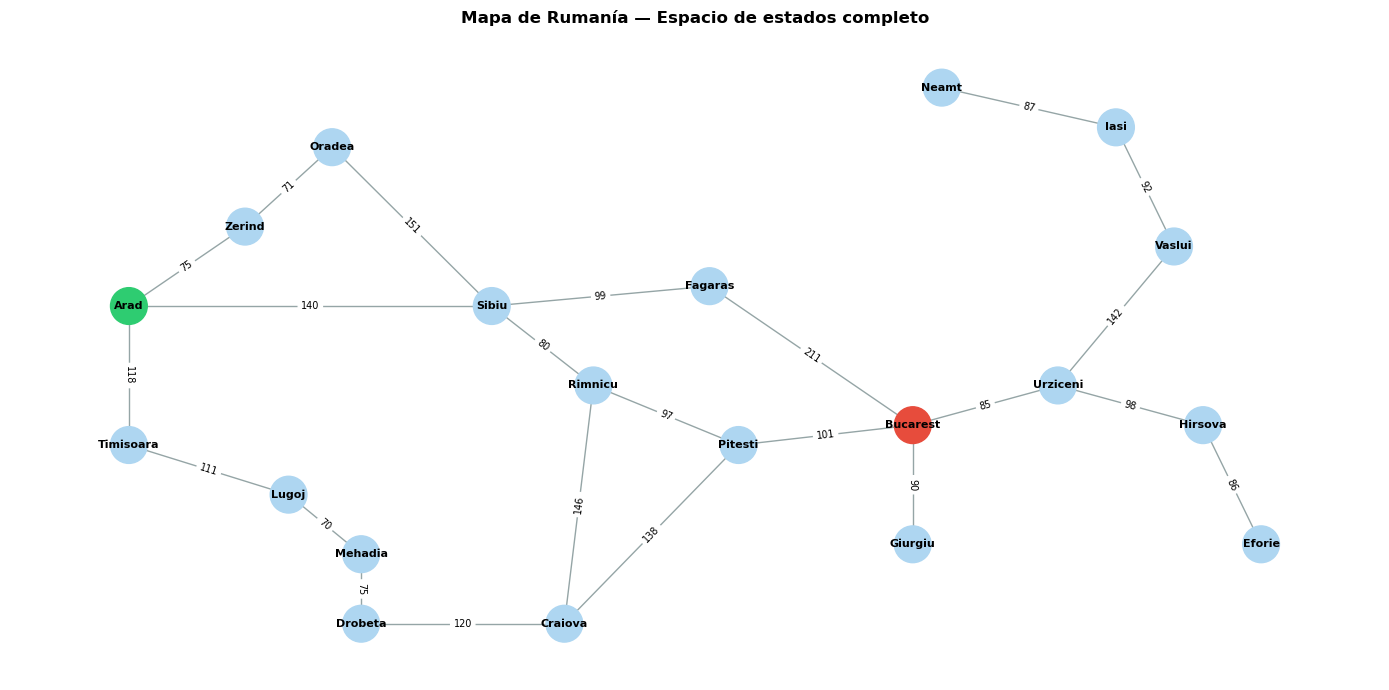

In [4]:
def build_graph(map_data):
    G = nx.Graph()
    for city, neighbors in map_data.items():
        for neighbor, dist in neighbors:
            G.add_edge(city, neighbor, weight=dist)
    return G


# Layout aproximado geográfico (reutilizable en los plots siguientes)
POS = {
    'Arad':       (0.0, 3.2),  'Zerind':    (0.8, 4.0),
    'Oradea':     (1.4, 4.8),  'Sibiu':     (2.5, 3.2),
    'Timisoara':  (0.0, 1.8),  'Lugoj':     (1.1, 1.3),
    'Mehadia':    (1.6, 0.7),  'Drobeta':   (1.6, 0.0),
    'Craiova':    (3.0, 0.0),  'Rimnicu':   (3.2, 2.4),
    'Fagaras':    (4.0, 3.4),  'Pitesti':   (4.2, 1.8),
    'Bucarest':   (5.4, 2.0),  'Giurgiu':   (5.4, 0.8),
    'Urziceni':   (6.4, 2.4),  'Hirsova':   (7.4, 2.0),
    'Eforie':     (7.8, 0.8),  'Vaslui':    (7.2, 3.8),
    'Iasi':       (6.8, 5.0),  'Neamt':     (5.6, 5.4),
}


def draw_romania(G, path=None, title='Mapa de Rumanía', ax=None, path_color='#e67e22'):
    node_colors = []
    for node in G.nodes():
        if node == INITIAL_STATE:
            node_colors.append('#2ecc71')
        elif node == GOAL_STATE:
            node_colors.append('#e74c3c')
        elif path and node in path:
            node_colors.append('#f39c12')
        else:
            node_colors.append('#aed6f1')

    path_edges = set()
    if path:
        path_edges = {(path[i], path[i+1]) for i in range(len(path)-1)}
        path_edges |= {(b, a) for a, b in path_edges}

    edge_colors = [path_color if (u, v) in path_edges else '#95a5a6' for u, v in G.edges()]
    edge_widths = [3.5 if (u, v) in path_edges else 1.0 for u, v in G.edges()]

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 7))

    nx.draw_networkx_nodes(G, POS, node_color=node_colors, node_size=700, ax=ax)
    nx.draw_networkx_labels(G, POS, font_size=8, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, POS, edge_color=edge_colors, width=edge_widths, ax=ax)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, POS, edge_labels=edge_labels, font_size=7, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')


G = build_graph(ROMANIA_MAP)
draw_romania(G, title='Mapa de Rumanía — Espacio de estados completo')
plt.tight_layout()
plt.show()

## 🧩 Paso 4: Formulación del Problema Informado

Extendemos el problema del notebook anterior agregando el método `heuristic(self, state)`.  
Este método es utilizado automáticamente por `greedy` y `astar` de `simpleai`.

In [5]:
class RomaniaInformada(SearchProblem):
    """Problema de Rumanía con heurística: distancia en línea recta a Bucarest."""

    def actions(self, state):
        return [neighbor for neighbor, _ in ROMANIA_MAP.get(state, [])]

    def result(self, state, action):
        return action

    def is_goal(self, state):
        return state == GOAL_STATE

    def cost(self, state, action, result):
        for neighbor, dist in ROMANIA_MAP.get(state, []):
            if neighbor == action:
                return dist
        return float('inf')

    def heuristic(self, state):
        """h(n): distancia en línea recta desde 'state' hasta Bucarest."""
        return H_BUCAREST.get(state, 0)


def get_path_and_cost(result):
    if result is None:
        return None, None
    path = [state for _, state in result.path()]
    cost = result.cost
    return path, cost


print("✅ Clase RomaniaInformada definida")
prob = RomaniaInformada(initial_state=INITIAL_STATE)
print(f"   h(Arad) = {prob.heuristic('Arad')} km  (línea recta a Bucarest)")
print(f"   h(Sibiu) = {prob.heuristic('Sibiu')} km")
print(f"   h(Bucarest) = {prob.heuristic('Bucarest')} km  (meta → h=0)")

✅ Clase RomaniaInformada definida
   h(Arad) = 366 km  (línea recta a Bucarest)
   h(Sibiu) = 253 km
   h(Bucarest) = 0 km  (meta → h=0)


## 🔍 Paso 5: Greedy Best-First

**Greedy** elige en cada paso el nodo que **parece más cercano a la meta** según $h(n)$, sin considerar el costo ya pagado.

$$f(n) = h(n)$$

- ✅ **Rápido**: expande pocos nodos
- ❌ **No óptimo**: puede tomar caminos costosos que parecen prometedores
- ⚠️ Puede quedar atrapado en bucles si no se usa `graph_search=True`

> 📌 Intuición: como alguien que siempre va en la dirección del destino en línea recta, ignorando que quizás haya un rodeo más rápido.

In [6]:
problem = RomaniaInformada(initial_state=INITIAL_STATE)
result_greedy = greedy(problem, graph_search=True)
path_greedy, cost_greedy = get_path_and_cost(result_greedy)

print("🔍 Greedy Best-First")
print(f"   Camino: {' → '.join(path_greedy)}")
print(f"   Costo total: {cost_greedy} km")
print(f"   Pasos: {len(path_greedy) - 1}")

# Analizar la decisión paso a paso
print("\n📋 Decisiones de Greedy en cada paso:")
for city in path_greedy:
    print(f"   {city:15s}  →  h = {H_BUCAREST.get(city, 0):3d} km")

🔍 Greedy Best-First
   Camino: Arad → Sibiu → Fagaras → Bucarest
   Costo total: 450 km
   Pasos: 3

📋 Decisiones de Greedy en cada paso:
   Arad             →  h = 366 km
   Sibiu            →  h = 253 km
   Fagaras          →  h = 176 km
   Bucarest         →  h =   0 km


## 🔍 Paso 6: A\* — El Algoritmo Estrella

**A\*** combina el costo real acumulado $g(n)$ con la estimación heurística $h(n)$:

$$f(n) = g(n) + h(n)$$

- ✅ **Completo**: siempre encuentra solución si existe
- ✅ **Óptimo**: garantizado si $h(n)$ es admisible
- ✅ **Eficiente**: expande muchos menos nodos que UCS gracias a la heurística

> 💡 A\* es el algoritmo de búsqueda más usado en la práctica: videojuegos, navegación GPS, robótica, planificación de rutas.

In [7]:
problem = RomaniaInformada(initial_state=INITIAL_STATE)
result_astar = astar(problem, graph_search=True)
path_astar, cost_astar = get_path_and_cost(result_astar)

print("⭐ A* — Búsqueda Heurística Óptima")
print(f"   Camino: {' → '.join(path_astar)}")
print(f"   Costo total: {cost_astar} km  ← camino óptimo")
print(f"   Pasos: {len(path_astar) - 1}")

# Analizar f(n) en cada nodo del camino
print("\n📋 Evaluación f(n) = g(n) + h(n) en cada nodo del camino:")
g = 0
prev = None
for city in path_astar:
    if prev:
        for neighbor, dist in ROMANIA_MAP[prev]:
            if neighbor == city:
                g += dist
                break
    h = H_BUCAREST.get(city, 0)
    f = g + h
    print(f"   {city:15s}  g={g:4d}  h={h:3d}  f={f:4d}")
    prev = city

⭐ A* — Búsqueda Heurística Óptima
   Camino: Arad → Sibiu → Rimnicu → Pitesti → Bucarest
   Costo total: 418 km  ← camino óptimo
   Pasos: 4

📋 Evaluación f(n) = g(n) + h(n) en cada nodo del camino:
   Arad             g=   0  h=366  f= 366
   Sibiu            g= 140  h=253  f= 393
   Rimnicu          g= 220  h=193  f= 413
   Pitesti          g= 317  h=100  f= 417
   Bucarest         g= 418  h=  0  f= 418


## 📊 Paso 7: Comparativa Greedy vs A\* vs UCS

Ejecutamos también UCS (sin heurística) para tener una referencia y comparar los tres enfoques.

In [8]:
# UCS sin heurística (usamos RomaniaInformada pero astar ignora h si usamos uniform_cost)
from simpleai.search import SearchProblem as SP

class RomaniaSinH(SP):
    def actions(self, state):
        return [n for n, _ in ROMANIA_MAP.get(state, [])]
    def result(self, state, action):
        return action
    def is_goal(self, state):
        return state == GOAL_STATE
    def cost(self, state, action, result):
        for n, d in ROMANIA_MAP.get(state, []):
            if n == action:
                return d
        return float('inf')

result_ucs = uniform_cost(RomaniaSinH(initial_state=INITIAL_STATE), graph_search=True)
path_ucs, cost_ucs = get_path_and_cost(result_ucs)

# Tabla comparativa
data = [
    ('Greedy Best-First', ' → '.join(path_greedy),  cost_greedy, len(path_greedy)-1,  'f(n) = h(n)',       '❌ No',  '✅ Muy rápido'),
    ('A*',               ' → '.join(path_astar),   cost_astar,  len(path_astar)-1,   'f(n) = g(n)+h(n)', '✅ Sí',  '✅ Eficiente'),
    ('UCS (sin h)',       ' → '.join(path_ucs),     cost_ucs,    len(path_ucs)-1,     'f(n) = g(n)',       '✅ Sí',  '⚠️ Más lento'),
]

df = pd.DataFrame(data, columns=['Algoritmo', 'Camino', 'Costo (km)', 'Pasos', 'Evaluación', 'Óptimo', 'Velocidad'])
print("\n📊 Comparativa: Búsqueda Informada vs No Informada\n")
print(df[['Algoritmo', 'Costo (km)', 'Pasos', 'Evaluación', 'Óptimo', 'Velocidad']].to_string(index=False))
print("\n📋 Caminos:")
for _, row in df.iterrows():
    print(f"   {row['Algoritmo']:20s}: {row['Camino']}")


📊 Comparativa: Búsqueda Informada vs No Informada

        Algoritmo  Costo (km)  Pasos       Evaluación Óptimo    Velocidad
Greedy Best-First         450      3      f(n) = h(n)   ❌ No ✅ Muy rápido
               A*         418      4 f(n) = g(n)+h(n)   ✅ Sí  ✅ Eficiente
      UCS (sin h)         418      4      f(n) = g(n)   ✅ Sí ⚠️ Más lento

📋 Caminos:
   Greedy Best-First   : Arad → Sibiu → Fagaras → Bucarest
   A*                  : Arad → Sibiu → Rimnicu → Pitesti → Bucarest
   UCS (sin h)         : Arad → Sibiu → Rimnicu → Pitesti → Bucarest


## 🗺️ Paso 8: Visualización Comparativa Greedy vs A\*

Graficamos los caminos de Greedy y A\* sobre el mapa. Notá cómo Greedy puede tomar un camino más largo porque solo mira hacia adelante, mientras que A\* balancea el costo ya pagado con la estimación.

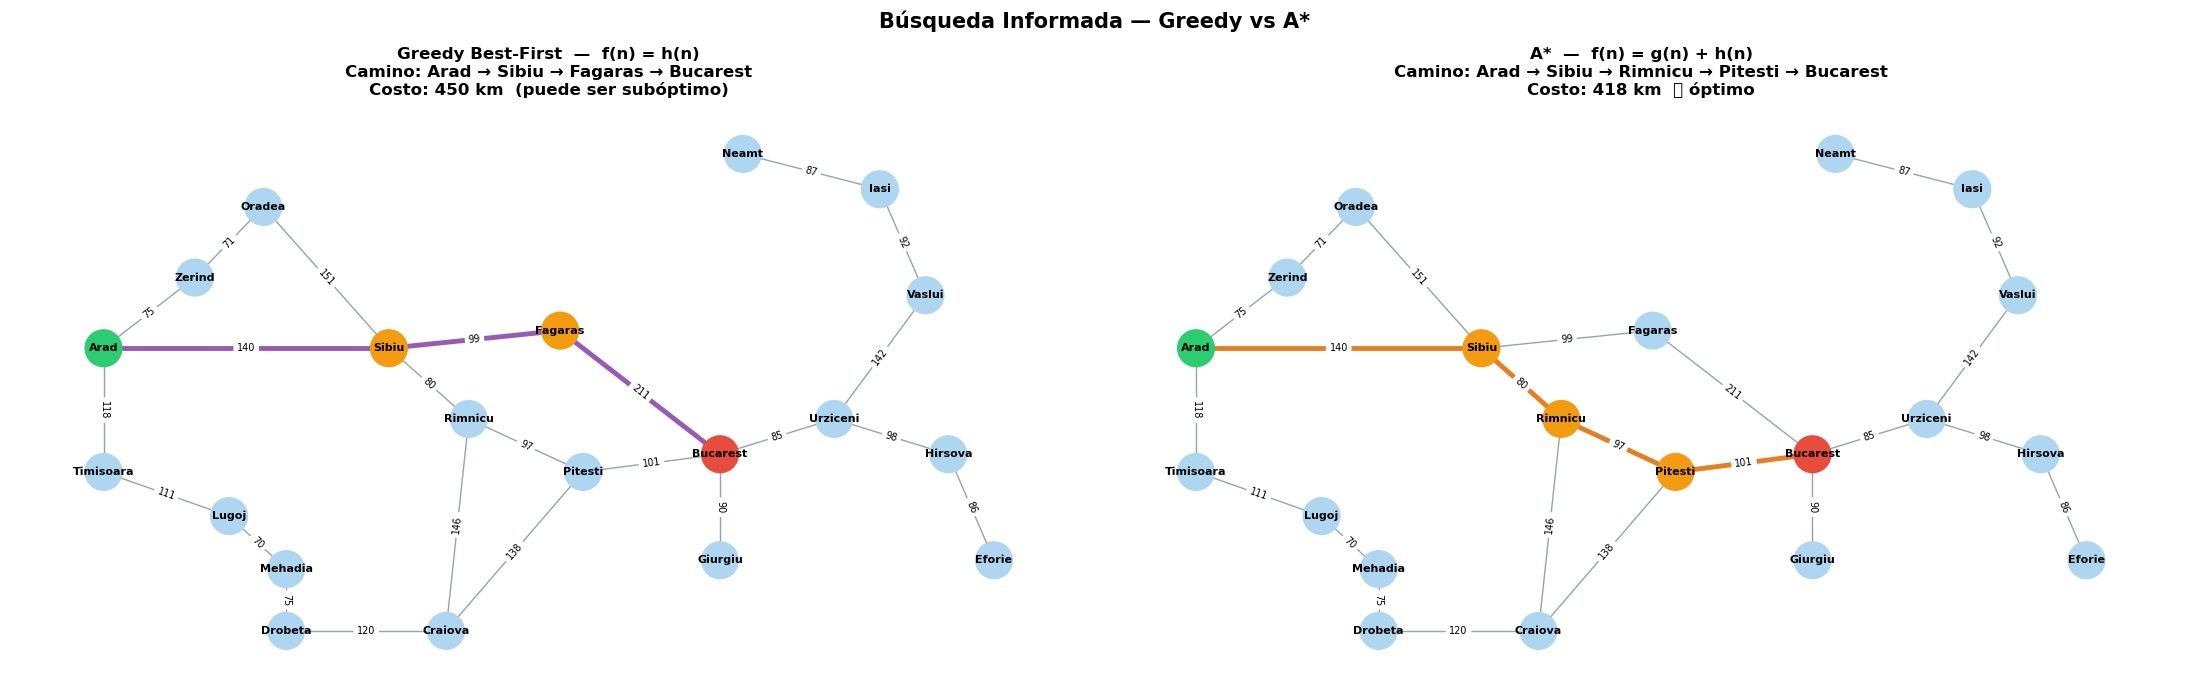

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

draw_romania(
    G, path=path_greedy,
    title=f'Greedy Best-First  —  f(n) = h(n)\nCamino: {" → ".join(path_greedy)}\nCosto: {cost_greedy} km  (puede ser subóptimo)',
    ax=axes[0],
    path_color='#9b59b6'
)

draw_romania(
    G, path=path_astar,
    title=f'A*  —  f(n) = g(n) + h(n)\nCamino: {" → ".join(path_astar)}\nCosto: {cost_astar} km  ✅ óptimo',
    ax=axes[1],
    path_color='#e67e22'
)

plt.suptitle('Búsqueda Informada — Greedy vs A*', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔍 Paso 9: IDA\* — Nota Conceptual

**IDA\*** (*Iterative Deepening A\**) es una variante de A\* que usa iteración por umbral en lugar de una cola de prioridad, reduciendo drásticamente el uso de memoria.

| Característica | A\* | IDA\* |
|----------------|-----|-------|
| **Óptimo** | ✅ Sí | ✅ Sí |
| **Memoria** | $O(b^d)$ — exponencial | $O(bd)$ — lineal |
| **Velocidad** | Más rápido | Puede reexpandir nodos |
| **Implementación** | Cola de prioridad | Recursión + umbral |

**Funcionamiento**:
1. Comienza con umbral $t_0 = h(\text{inicio})$
2. Ejecuta DFS descartando nodos con $f(n) > t$
3. Si no encuentra solución, incrementa el umbral al menor $f$ descartado
4. Repite hasta encontrar la meta

> 📌 `simpleai` no incluye IDA\* de forma nativa, pero puede implementarse manualmente o usando la librería `aima3`. Para problemas de tamaño moderado como el mapa de Rumanía, A\* es suficiente.

In [10]:
# Implementación manual de IDA* para ilustrar el concepto

def ida_star(problem_map, heuristic, initial, goal):
    """Implementación de IDA* sobre un diccionario de mapa."""

    def search(path, g, threshold):
        node = path[-1]
        f = g + heuristic[node]
        if f > threshold:
            return f, None          # poda: f supera el umbral
        if node == goal:
            return -1, list(path)   # encontrado

        minimum = float('inf')
        for neighbor, dist in problem_map.get(node, []):
            if neighbor not in path:  # evita ciclos
                path.append(neighbor)
                result, found_path = search(path, g + dist, threshold)
                if result == -1:
                    return -1, found_path
                if result < minimum:
                    minimum = result
                path.pop()
        return minimum, None

    threshold = heuristic[initial]
    path = [initial]
    iterations = 0
    while True:
        iterations += 1
        result, found_path = search(path, 0, threshold)
        if result == -1:
            # Calcular costo total
            total_cost = sum(
                dist
                for i in range(len(found_path) - 1)
                for neighbor, dist in problem_map[found_path[i]]
                if neighbor == found_path[i + 1]
            )
            return found_path, total_cost, iterations
        if result == float('inf'):
            return None, None, iterations
        threshold = result


path_ida, cost_ida, iters = ida_star(ROMANIA_MAP, H_BUCAREST, INITIAL_STATE, GOAL_STATE)

print("⭐ IDA* — Iterative Deepening A*")
print(f"   Camino: {' → '.join(path_ida)}")
print(f"   Costo total: {cost_ida} km  ← camino óptimo")
print(f"   Iteraciones de umbral: {iters}")
print(f"   Pasos: {len(path_ida) - 1}")
print(f"\n✅ IDA* coincide con A*: {path_ida == path_astar}")

⭐ IDA* — Iterative Deepening A*
   Camino: Arad → Sibiu → Rimnicu → Pitesti → Bucarest
   Costo total: 418 km  ← camino óptimo
   Iteraciones de umbral: 6
   Pasos: 4

✅ IDA* coincide con A*: True


## 📊 Paso 10: Comparativa Final — Todos los Algoritmos

Reunimos los resultados de ambos notebooks para una comparativa completa.

In [11]:
comparativa = [
    # (Algoritmo, Tipo, f(n), Costo, Pasos, Óptimo, Memoria)
    ('BFS',            'No informada', 'nivel',          '---',           '---', '✅ (costo unif.)', '⚠️ Alta'),
    ('DFS',            'No informada', 'profundidad',    '---',           '---', '❌ No',            '✅ Baja'),
    ('UCS',            'No informada', 'g(n)',           f'{cost_ucs}',   f'{len(path_ucs)-1}',   '✅ Sí', '⚠️ Media'),
    ('IDS',            'No informada', 'DFS+límite',     '---',           '---', '✅ (costo unif.)', '✅ Baja'),
    ('Greedy',         'Informada',    'h(n)',           f'{cost_greedy}',f'{len(path_greedy)-1}','❌ No', '✅ Muy rápido'),
    ('A*',             'Informada',    'g(n)+h(n)',      f'{cost_astar}', f'{len(path_astar)-1}', '✅ Sí', '⚠️ Media'),
    ('IDA*',           'Informada',    'g(n)+h(n)+iter', f'{cost_ida}',   f'{len(path_ida)-1}',   '✅ Sí', '✅ Baja'),
]

df_final = pd.DataFrame(comparativa,
    columns=['Algoritmo', 'Tipo', 'f(n)', 'Costo Arad→Buc.', 'Pasos', 'Óptimo', 'Memoria'])

print("\n📊 Comparativa completa — Búsqueda en IA\n")
print(df_final.to_string(index=False))


📊 Comparativa completa — Búsqueda en IA

Algoritmo         Tipo           f(n) Costo Arad→Buc. Pasos          Óptimo      Memoria
      BFS No informada          nivel             ---   --- ✅ (costo unif.)      ⚠️ Alta
      DFS No informada    profundidad             ---   ---            ❌ No       ✅ Baja
      UCS No informada           g(n)             418     4            ✅ Sí     ⚠️ Media
      IDS No informada     DFS+límite             ---   --- ✅ (costo unif.)       ✅ Baja
   Greedy    Informada           h(n)             450     3            ❌ No ✅ Muy rápido
       A*    Informada      g(n)+h(n)             418     4            ✅ Sí     ⚠️ Media
     IDA*    Informada g(n)+h(n)+iter             418     4            ✅ Sí       ✅ Baja


## 🎓 Resumen y Conclusiones

En este notebook aprendimos:

1. 🧭 **Heurísticas admisibles**: qué son, cómo construirlas y por qué la distancia en línea recta es admisible
2. 🔍 **Greedy Best-First**: rápido pero no óptimo — solo mira hacia adelante con $f(n) = h(n)$
3. ⭐ **A\***: combina costo real y heurística con $f(n) = g(n) + h(n)$, óptimo y eficiente
4. ⭐ **IDA\***: variante de A\* con uso de memoria lineal, implementada manualmente con recursión por umbral
5. 📊 **Comparativa completa**: todos los algoritmos (ciegos e informados) sobre el mismo problema

### Puntos clave

- **A\* es óptimo** siempre que la heurística sea admisible: $h(n) \leq h^*(n) \quad \forall n$
- **Greedy** expande muy pocos nodos pero puede elegir caminos subóptimos al ignorar $g(n)$
- La diferencia clave entre ambos: Greedy usa $f = h(n)$, A\* usa $f = g(n) + h(n)$
- En el Mapa de Rumanía, A\*, UCS e IDA\* coinciden en el camino óptimo de **418 km**
- **IDA\*** logra la optimalidad de A\* con el uso de memoria de IDS

### 🚀 ¿Qué sigue?

- ♟️ **Búsqueda Adversaria (Minimax, Alpha-Beta Pruning)**: cuando hay un oponente que también elige acciones — juegos de dos jugadores
- 🎲 **Búsqueda Local**: Hill Climbing, Simulated Annealing, Algoritmos Genéticos — optimizar sin importar el camino
- 📋 **Planificación (PDDL)**: formalizar dominios complejos con precondiciones y efectos usando `pyperplan`

> 📚 **Referencias:**
> - Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
> - Hart, P., Nilsson, N. & Raphael, B. (1968). [A Formal Basis for the Heuristic Determination of Minimum Cost Paths](https://doi.org/10.1109/TSSC.1968.300136). *IEEE Transactions on Systems Science and Cybernetics*, 4(2), 100–107.
> - Korf, R. (1985). [Depth-first iterative-deepening: An optimal admissible tree search](https://doi.org/10.1016/0004-3702(85)90084-0). *Artificial Intelligence*, 27(1), 97–109.
> - [simpleai — documentación oficial](https://simpleai.readthedocs.io/)

---

© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas

Este notebook se distribuye bajo licencia [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).